# **Linear and Logistic Regression: Wine Quality Dataset**
## AI 221 Assignment 03

Submitted by: **Pangilinan, Reignel Bernice** \\


Dataset reference: \\
Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Wine Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C56S3T.

\\

Code is based on Dr. K. Pilario's work in https://github.com/kspilario/AI221/blob/main/Linear_and_Logistic_Regression/ridge_holdout_autompg.ipynb

In [ ]:
import numpy as np    # Import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import time

!pip install ucimlrepo    # uncomment if making an error
from ucimlrepo import fetch_ucirepo   # Dataset is from UCI ML repository, packaged for easier import to Python

# Fetch dataset
wine_quality = fetch_ucirepo(id = 186)

# Data (as pandas dataframes)
X = wine_quality.data.features    # Features
y = wine_quality.data.targets   # Targets or labels

print(wine_quality.metadata)    # Display datatype of features and label
print(wine_quality.variables)   # Display variable information

wine = pd.concat([X, y], axis = 1)    # Arrange the data into columns of features, last column as labels using pandas
display(wine)   # Show the dataframe of features and labels

print(f'Wine quality data has {X.shape[1]} features and {X.shape[0]} instances.')   # Show the number of features and instances in the data

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


Wine quality data has 11 features and 6497 instances.


## **Visualize correlogram (or pairplot)**

Pairplots are simply scatterplots of the combinations of the features within the dataset. To better determine which features correlate with the other in terms of the target (labels), we can generate a correlation matrix. The values in the correlation matrix give us an idea on which features are highly correlated or not with each other.


<Figure size 800x800 with 0 Axes>

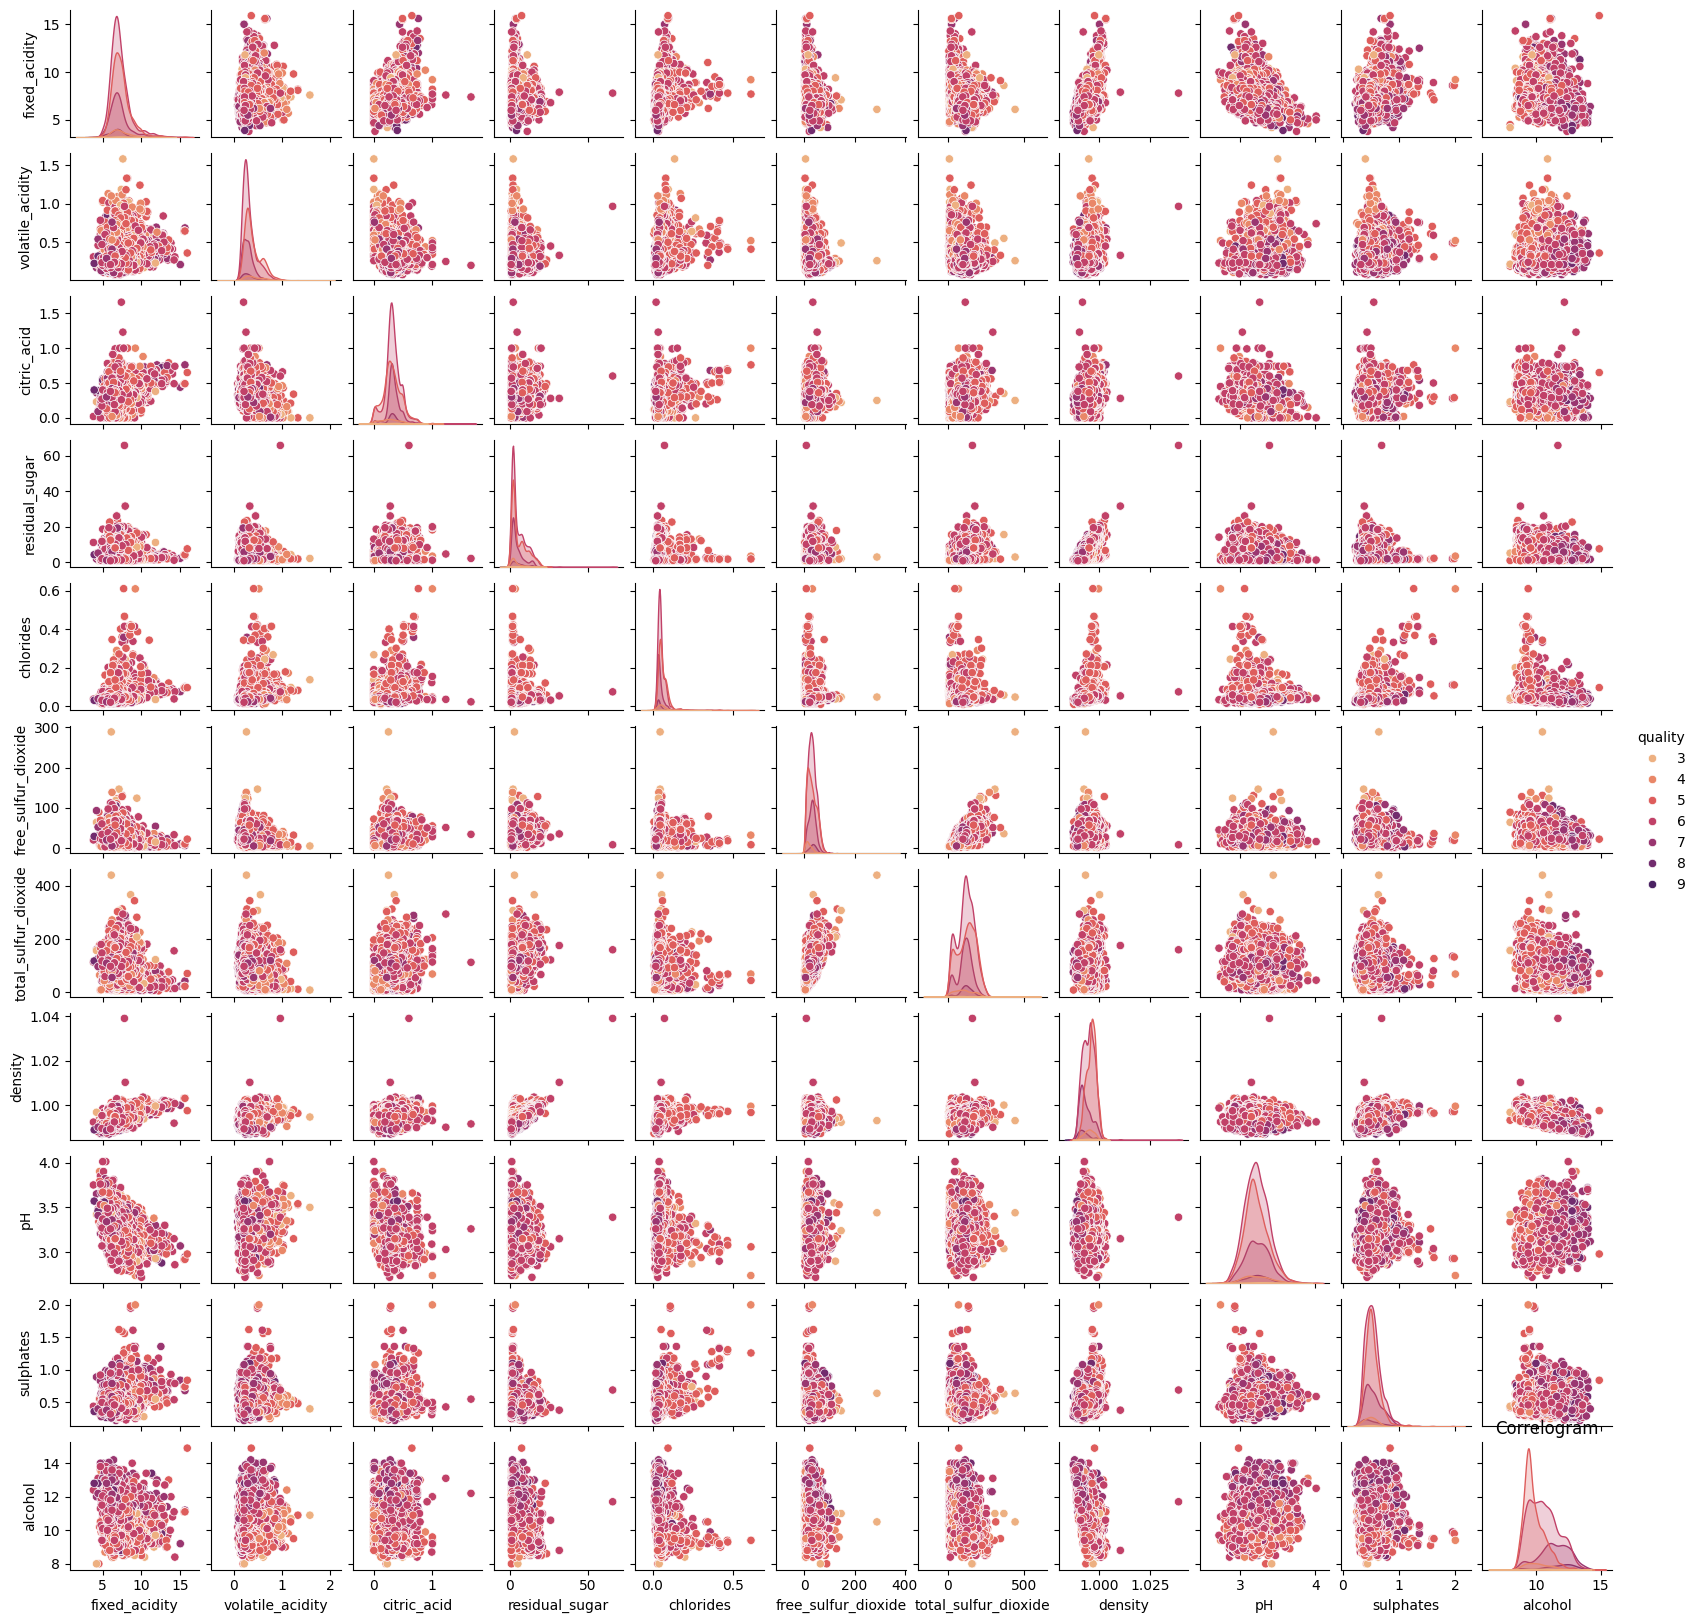

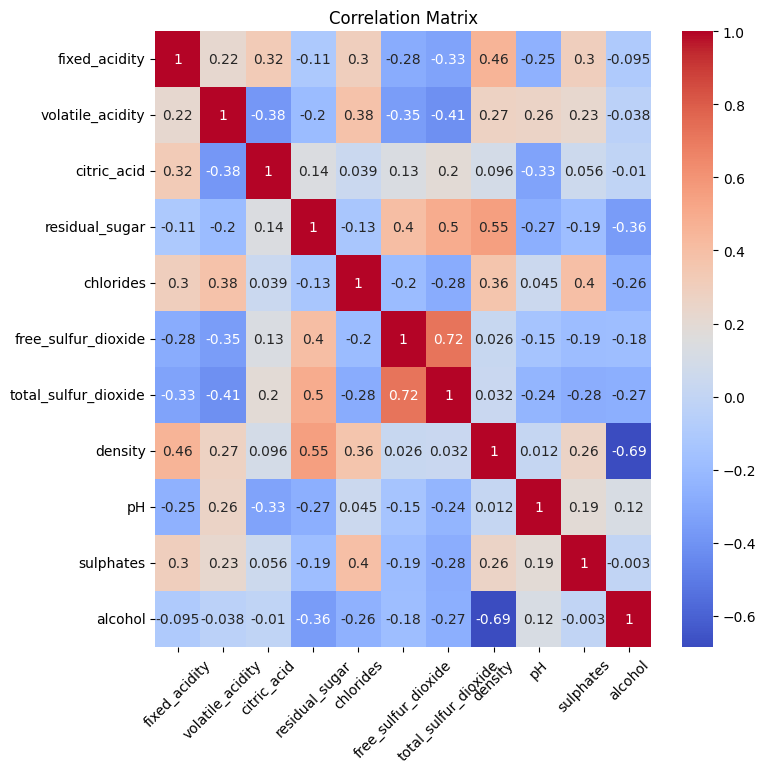

In [ ]:
# Create paiprlots of the features in the dataset
plt.figure(figsize = (8, 8))   # Initialize the figure size
sns.pairplot(wine, hue = "quality", height = 1.5, palette = "flare")   # Use seaborn to plot multiple pairwise distributions within data (note: use data not scaled here)
plt.title('Correlogram')   # Add a title
plt.show()    # Display the plot, diagonal contains the univariate plots

# Create a correlation matrix to better interpret the pairplots
plt.figure(figsize = (8, 8))   # Initialize the figure size
corr_matrix = wine.iloc[:, :X.shape[1]].corr()  # Compute for the correlation matrix
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm")    # Use seaborn to plot a heatmap of the correlation matrix
plt.title("Correlation Matrix")   # Add a title
plt.xticks(rotation = 45)   # Customize the text along x-axis
plt.show()    # Display the plot

## **Linear Regression: Wine quality as targets**

Dimensions of the training set: (4547, 11)
Dimensions of the validation set: (975, 11)
Dimensions of the test set: (975, 11)

Alpha: 0.0
	Coefficients: [ 0.09161793 -0.21061514 -0.01086533  0.20974797 -0.02915725  0.09650607
 -0.14097528 -0.16871386  0.07430959  0.1151029   0.31232714]
	Intercept: [5.81988124]
	Training accuracy (R2): 0.293757973078256
	Validation accuracy (R2): 0.2949418476741651

Alpha: 0.005
	Coefficients: [ 0.09161593 -0.21061512 -0.01086508  0.20974526 -0.02915764  0.09650574
 -0.14097453 -0.16871018  0.07430839  0.11510239  0.31232838]
	Intercept: [5.81988124]
	Training accuracy (R2): 0.2937579730764157
	Validation accuracy (R2): 0.29494180933262815

Alpha: 0.01
	Coefficients: [ 0.09161393 -0.21061511 -0.01086483  0.20974254 -0.02915804  0.0965054
 -0.14097378 -0.16870651  0.07430719  0.11510188  0.31232962]
	Intercept: [5.81988124]
	Training accuracy (R2): 0.2937579730708948
	Validation accuracy (R2): 0.29494177098807306

Alpha: 0.1
	Coefficients: [ 0.09157796 -

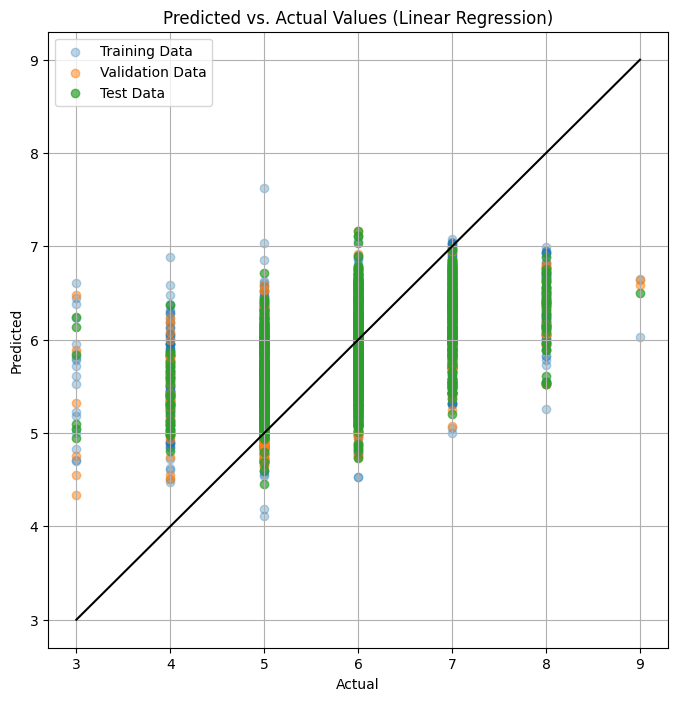

In [ ]:
### Without color
# Split the dataset into training, validation, and test sets
X_train, X_2, y_train, y_2 = train_test_split(X, y, test_size = 0.3, random_state = 0)  # Do a 70-30 train-test split on the data
X_val, X_test, y_val, y_test = train_test_split(X_2, y_2, test_size = 0.5, random_state = 0)  # Do a 50-50 validation-test set on the test data

print(f"Dimensions of the training set: {X_train.shape}")  # Check the shape of each set
print(f"Dimensions of the validation set: {X_val.shape}")
print(f"Dimensions of the test set: {X_test.shape}")

# Search over diffrent regularization parameter values for the value that gives the best validation accuracy
max_R2 = 0
best_alpha = 0
best_model = 0
alphas = np.array([0, 0.005, 0.01, 0.1, 0.5, 1, 5, 10, 50, 100]) # numpy array of regularization parameter values

for alpha in alphas:  # Iterate over each alpha
  model = make_pipeline(StandardScaler(), # Generate the model, StandardScaler() as the transformer
                      Ridge(alpha = alpha)).fit(X_train, y_train) # Ridge() as the regressor
  print(f"\nAlpha: {alpha}")  # Print output for every regularization parameter tested
  train_R2 = model.score(X_train, y_train)  # Get the R2 of the training data
  val_R2 = model.score(X_val, y_val)  # Get the R2 of the validation data
  print(f"\tCoefficients: {model[1].coef_}")  # Print the coefficients of the regression model
  print(f"\tIntercept: {model[1].intercept_}")  # Print the intercept of the regression model
  print(f"\tTraining accuracy (R2): {train_R2}")  # Print the R2 of the training data
  print(f"\tValidation accuracy (R2): {val_R2}")  # Print the R2 of the validation data
  if val_R2 > max_R2:
    max_R2 = val_R2
    best_alpha = alpha
    best_model = model

print(f"\nBest alpha: {best_alpha}")  # Print the value for the best alpha
print(f"Coefficients: {best_model[1].coef_}") # Print the value of the coefficients given the best alpha
print(f"Intercept: {best_model[1].intercept_}") # Print the value of the intercept given the best alpha

# Use the best model to make predictions
y_train_pred = best_model.predict(X_train)  # Using the training data
y_val_pred = best_model.predict(X_val)  # Using the validation data
y_test_pred = best_model.predict(X_test)  # Using the test data
print(f"\nTest accuracy (R2): {best_model.score(X_test, y_test)}")  # Print the R2 of the test data

# Plot the actual vs. predicted values
plt.figure(figsize = (8, 8))  # Initialize figure size
plt.scatter(y_train, y_train_pred, label = "Training Data", alpha = 0.3) # Plot the training data vs. predicted training
plt.scatter(y_val, y_val_pred, label = "Validation Data", alpha = 0.5) # Plot the validation data vs. predicted validation
plt.scatter(y_test, y_test_pred, label = "Test Data", alpha = 0.7) # Plot the test data vs. predicted test
plt.xlabel("Actual") # x-axis label
plt.ylabel("Predicted")  # y-axis title
plt.title("Predicted vs. Actual Values (Linear Regression)") # Add a plot title
plt.plot(np.array([3, 9]), np.array([3, 9]), color = "k", label = "_nolegend_") # Add a straight line for reference
plt.grid()  # Add grid lines
plt.legend()  # Show the legend
plt.show()  # Display

By performing linear regression on the data, wine color features and using the model to predict wine quality, we see may observe the following:

  * The model generally suffers from a low accuracy. The value for the training, validation, and testing accuracies were only about **0.29** for the training ad validation and about **0.28** for the test.
  * Despite the low value of the R2, the almost similar values imply that there is neither underfitting nor overfitting of the model.
  * The actual vs. predicted wine quality for the training, validation, and test sets do not fluctuate about a line. This might expected because the labels are categorical and are not continuous.

\\

Based on these observations, the following conclusions may be made:

  * If we have wine quality as the targets or labels, doing regression may not be the best approach.
  * Having the features and labels as the wine quality as it is, I think the dataset is better suited for multiclass classification problems. Thus, it is recommended that this task is best approached as a multiclass classification problem.
  * Although the R2 values are not that high, the model somewhat fits the validation and test sets well because the difference between the obtained values are not that significant. Again, this means that there is no underfitting or overfitting.
  * If there was an additional column indicating the price of wine, then linear regression would *probably* be better suited to the dataset and task of predicting the price of wine given the features. Then, the labels would be continuous in nature.

## **Logistic Regression: Classification according to wine color**

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,white
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,white
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,white
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,white


Dimensions of the training set: (4547, 12)
Dimensions of the validation set: (975, 12)
Dimensions of the test set: (975, 12)

C: 0.001
	Coefficients: [[-0.29076217 -0.37467511  0.08963357  0.18216646 -0.2771595   0.16634431
   0.42060401 -0.29118412 -0.19211768 -0.2622665  -0.00853442  0.00989234]]
	Intercept: [0.57171016]
	Training accuracy: 0.9830657576424016
	Validation accuracy: 0.9815384615384616

C: 0.01
	Coefficients: [[-0.57340707 -0.73246178  0.17271954  0.43774044 -0.5353267   0.11546393
   1.03032599 -0.81636751 -0.40783326 -0.48600738 -0.13584261 -0.08216921]]
	Intercept: [1.50347618]
	Training accuracy: 0.990763140532219
	Validation accuracy: 0.9938461538461538

C: 0.1
	Coefficients: [[-0.6166576  -0.99508133  0.24189544  1.11518743 -0.72103901 -0.22592773
   1.94394799 -2.04966822 -0.52114023 -0.59770026 -0.62140065 -0.1970319 ]]
	Intercept: [2.54223832]
	Training accuracy: 0.9934022432372993
	Validation accuracy: 0.9938461538461538

C: 1.0
	Coefficients: [[ 0.13492236 -0

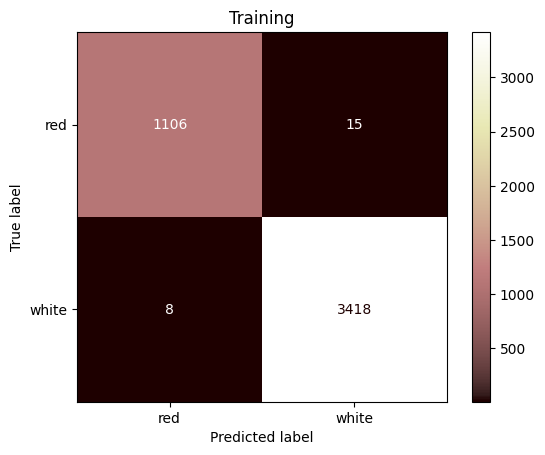

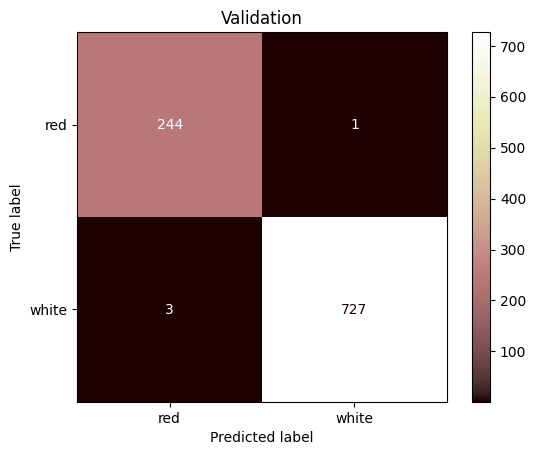

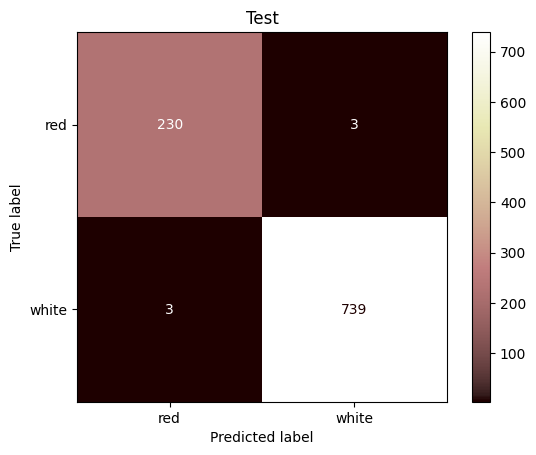


Test accuracy: 0.9938461538461538
Classification report:
              precision    recall  f1-score   support

         red       0.99      0.99      0.99       233
       white       1.00      1.00      1.00       742

    accuracy                           0.99       975
   macro avg       0.99      0.99      0.99       975
weighted avg       0.99      0.99      0.99       975



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

wine_with_color = wine_quality.data.original  # Wine dataset with color
display(wine_with_color)  # Show wine quality dataset with wine color

X = wine_with_color.iloc[:, :-1]  # Features
y = wine_with_color.iloc[:, -1]   # Labels

# Split the dataset into training, validation, and test sets
X_train, X_2, y_train, y_2 = train_test_split(X, y, test_size = 0.3, random_state = 0)  # Do a 70-30 train-test split on the data
X_val, X_test, y_val, y_test = train_test_split(X_2, y_2, test_size = 0.5, random_state = 0)  # Do a 50-50 validation-test set on the test data

print(f"Dimensions of the training set: {X_train.shape}")  # Check the shape of each set
print(f"Dimensions of the validation set: {X_val.shape}")
print(f"Dimensions of the test set: {X_test.shape}")

# Search over diffrent regularization parameter values for the value that gives the best validation accuracy
max_accuracy = 0
best_C = 0
best_model = 0
C_values = np.array([0.001, 0.01, 0.1, 1, 10, 100, 1000]) # numpy array of regularization parameter values

for C in C_values:  # Iterate over each C
  model = make_pipeline(StandardScaler(), # Generate the model, StandardScaler() as the transformer
                      LogisticRegression(C = C, solver = 'liblinear', penalty = 'l2', random_state = 0)).fit(X_train, y_train) # LogisticRegression() as the classifier
  print(f"\nC: {C}")  # Print output for every regularization parameter tested
  train_accuracy = model.score(X_train, y_train)  # Get the accuracy of the training data
  val_accuracy = model.score(X_val, y_val)  # Get the accuracy of the validation data
  print(f"\tCoefficients: {model[1].coef_}")  # Print the coefficients of the logistic regression model
  print(f"\tIntercept: {model[1].intercept_}")  # Print the intercept of the logistic regression model
  print(f"\tTraining accuracy: {train_accuracy}")  # Print the accuracy of the training data
  print(f"\tValidation accuracy: {val_accuracy}")  # Print the accuracy of the validation data
  if val_accuracy > max_accuracy:
    max_accuracy = val_accuracy
    best_C = C
    best_model = model

print(f"\nBest C: {best_C}")  # Print the value for the best C
print(f"Coefficients: {best_model[1].coef_}") # Print the value of the coefficients given the best C
print(f"Intercept: {best_model[1].intercept_}") # Print the value of the intercept given the best C

# Plot the confusion matrix
y_training_pred = best_model.predict(X_train) # Predicted labels using training data
y_validation_pred = best_model.predict(X_val) # Predicted labels using validation data
y_test_pred = best_model.predict(X_test) # Predicted labels using test data

cm_training = confusion_matrix(y_train, y_training_pred) # Confusion matrix using training data
ConfusionMatrixDisplay(cm_training, display_labels = ["red", "white"]).plot(cmap = "pink") # Plot confusion matrix using training data
plt.title("Training")
plt.show()

cm_validation = confusion_matrix(y_val, y_validation_pred) # Confusion matrix using validation data
ConfusionMatrixDisplay(cm_validation, display_labels = ["red", "white"]).plot(cmap = "pink") # Plot confusion matrix using validation data
plt.title("Validation")
plt.show()

cm_test = confusion_matrix(y_test, y_test_pred) # Confusion matrix using test data
ConfusionMatrixDisplay(cm_test, display_labels = ["red", "white"]).plot(cmap = "pink") # Plot confusion matrix using test data
plt.title("Test")
plt.show()

print(f"\nTest accuracy: {best_model.score(X_test, y_test)}")  # Print the accuracy of the test data
print(f"Classification report:\n{classification_report(y_test, y_test_pred)}")  # Print the classification report of the results using the test set

Doing classification according to wine color, after adding the column corresponding to the wine color in the data, makes much more sense than doing linear regression with the wine quality as the labels. This is evident in the high values for accuracy obtained by comparing the predicted labels to the true labels. Additionally, the classification report says that the average precision, recall, and F1 score of the logistic regression model stayed at **0.99**, which implies that the model classifies unseen data almost perfectly.